In [149]:
from wordcloud import WordCloud
from PIL import Image
import numpy as np
import io
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rc('font', family = 'Malgun Gothic')

In [150]:
df_merged_total = pd.read_csv("data/merged_data_total.csv")
df_merged_back = pd.read_csv("data/merged_data_backend.csv")
df_merged_front = pd.read_csv("data/merged_data_frontend.csv")

In [151]:
def create_wordcloud(df, shape_text, output_path=None):
    """
    시리즈 데이터로부터 워드클라우드 생성
    :param shape_text: 워드클라우드 모양이 될 텍스트
    :param output_path: 저장 경로 (None이면 저장 안함)
    """
    try:
        #텍스트 모양 마스크 생성
        fig, ax = plt.subplots(figsize=(15, 5))
        ax.text(0.5, 0.5, shape_text, fontsize=300, 
                ha='center', va='center', fontweight='bold', fontfamily='sans-serif')
        ax.axis('off')
        
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0, transparent=True)
        buf.seek(0)
        mask = np.array(Image.open(buf))
        plt.close()
        
        text = str(list(df['skill']))
        
        #워드클라우드 생성
        wordcloud = WordCloud(
            font_path='malgun.ttf',
            width=1400,
            height=1400,
            background_color='white',
            mask=mask,
            colormap='Dark2',
            max_words = 250,
            relative_scaling=0.3 # 빈도수 차이를 더 크게 반영
        ).generate(text)
        
        
        #결과 출력
        plt.figure(figsize=(10, 10))
        plt.imshow(wordcloud)
        plt.axis('off')
        # plt.title(f'"{shape_text}" 모양의 기술 스택 워드클라우드', pad=20)
        plt.show()
        
        #파일 저장
        if output_path:
            wordcloud.to_file(output_path)
            print(f"워드클라우드가 저장되었습니다: {output_path}")
            
        return wordcloud
        
    except Exception as e:
        print(f"에러 발생: {str(e)}")
        return None

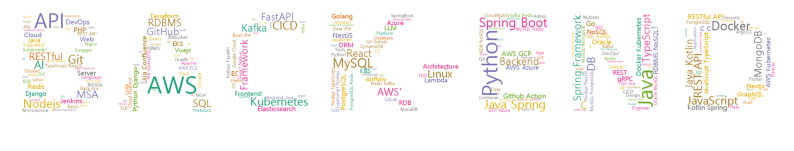

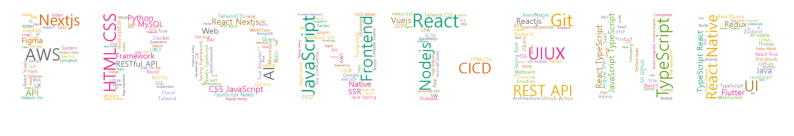

In [152]:
create_wordcloud(df_merged_back, "BACK-END", None)
create_wordcloud(df_merged_front, "FRONT-END", None)